🧠 Memulai pelatihan Agen Agresif (120.000 langkah)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -782     |
| time/              |          |
|    fps             | 4965     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -933        |
| time/                   |             |
|    fps                  | 3488        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013360713 |
|    clip_fraction        | 0.229       |
|    cli

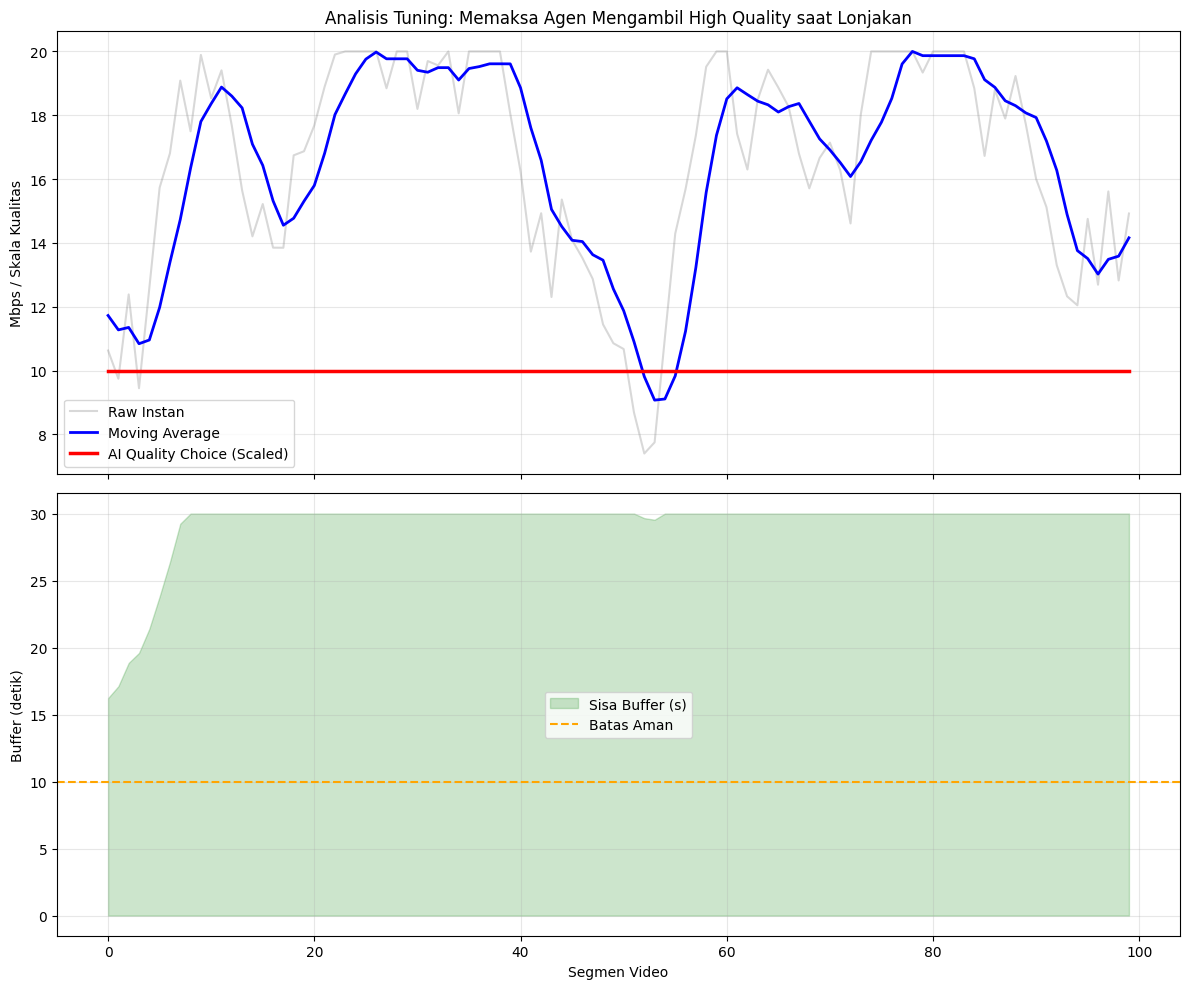


--- Cuplikan Hasil Tuning ---
    Step     Avg_TP     Buffer Quality
40    40  18.858501  30.000000       2
41    41  17.603720  30.000000       2
42    42  16.589769  30.000000       2
43    43  15.050796  30.000000       2
44    44  14.512317  30.000000       2
45    45  14.082321  30.000000       2
46    46  14.042500  30.000000       2
47    47  13.630619  30.000000       2
48    48  13.458856  30.000000       2
49    49  12.558002  30.000000       2
50    50  11.875051  30.000000       2
51    51  10.906610  30.000000       2
52    52   9.812786  29.657890       2
53    53   9.073604  29.539448       2
54    54   9.110165  30.000000       2


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

class SmoothedShakaEnv(gym.Env):
    """
    Simulator Shaka NDN dengan fitur Moving Average Throughput.
    Agen melihat tren rata-rata, namun didorong untuk lebih berani (Aggressive).
    """
    def __init__(self, window_size=5):
        super(SmoothedShakaEnv, self).__init__()
        self.window_size = window_size
        self.throughput_history = deque(maxlen=window_size)
        self.rtt_history = deque(maxlen=window_size)
        
        # Action: 0=Low (0.5), 1=Mid (2.5), 2=High (8.0 Mbps)
        self.action_space = spaces.Discrete(3)
        self.bitrates = [0.5, 2.5, 8.0]
        
        # Observation Space
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )
        self.state = None
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        initial_tp = 12.0 # Mulai dengan internet yang cukup baik
        initial_rtt = 40.0
        for _ in range(self.window_size):
            self.throughput_history.append(initial_tp)
            self.rtt_history.append(initial_rtt)
            
        self.state = np.array([15.0, initial_tp, 1.0, initial_rtt, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, _, last_qual, _, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        # 1. Simulasi Realitas (Angka Instan dengan Fluktuasi)
        raw_throughput = np.clip(self.throughput_history[-1] + np.random.uniform(-3.0, 3.5), 0.5, 20.0)
        raw_rtt = np.clip(self.rtt_history[-1] + np.random.uniform(-15, 15), 10, 500)
        
        seg_dur = 5.0
        download_time = (chosen_bitrate * seg_dur / (raw_throughput + 0.1)) + (raw_rtt / 1000.0)
        
        stalling = max(0, download_time - buffer)
        new_buffer = max(0, buffer - download_time) + seg_dur
        new_buffer = min(new_buffer, 30.0)

        # 2. Update History & Smoothing
        self.throughput_history.append(raw_throughput)
        self.rtt_history.append(raw_rtt)
        
        avg_throughput = sum(self.throughput_history) / len(self.throughput_history)
        avg_rtt = sum(self.rtt_history) / len(self.rtt_history)

        # 3. Logika Reward yang di-Tuning (Lebih Berani)
        # Dasar reward berdasarkan bitrate (Bitrate 8.0 dapat poin jauh lebih besar)
        reward = (chosen_bitrate ** 1.2) 

        if stalling > 0:
            reward -= 250.0 # Penalti macet sangat berat
            
        # Switching Penalty (Dipertahankan agar tidak Flicker)
        reward -= abs(action - last_qual) * 4.0
        
        # INSENTIF KEBERANIAN: Jika buffer sehat, wajib pilih kualitas tinggi
        if new_buffer > 20.0:
            if action == 2:
                reward += 15.0 # Bonus besar pilih High saat aman
            elif action == 0:
                reward -= 15.0 # Hukuman jika pilih Low saat buffer melimpah

        # PENALTI PELIT: Jika internet kencang tapi kualitas rendah
        if avg_throughput > 10.0 and action < 2:
            reward -= 10.0

        # Update State dengan nilai Smoothing
        self.state = np.array([new_buffer, avg_throughput, float(action), avg_rtt, 0.0], dtype=np.float32)
        
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {"raw_tp": raw_throughput}

def run_experiment():
    print("🧠 Memulai pelatihan Agen Agresif (120.000 langkah)...")
    env = SmoothedShakaEnv(window_size=5)
    
    # Tuning PPO: ent_coef ditingkatkan agar lebih berani eksplorasi kualitas High
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.00025, ent_coef=0.02)
    model.learn(total_timesteps=120000)
    
    # Testing
    obs, _ = env.reset()
    history = []
    for i in range(100):
        # Skenario internet dengan lonjakan besar
        if 40 <= i <= 70:
            # Simulasi lonjakan internet ke 15-18 Mbps
            obs[1] = np.random.uniform(14.0, 18.0) 
            
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        
        history.append({
            'Step': i,
            'Raw_TP': info['raw_tp'],
            'Avg_TP': obs[1],
            'Buffer': obs[0],
            'Quality': action
        })

    df = pd.DataFrame(history)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot 1: Kecepatan Jaringan vs Keputusan AI
    ax1.plot(df['Step'], df['Raw_TP'], label='Raw Instan', color='gray', alpha=0.3)
    ax1.plot(df['Step'], df['Avg_TP'], label='Moving Average', color='blue', linewidth=2)
    # Skala visual: Action 0->2, 1->6, 2->10
    ax1.step(df['Step'], df['Quality'] * 4 + 2, label='AI Quality Choice (Scaled)', color='red', linewidth=2.5)
    ax1.set_title("Analisis Tuning: Memaksa Agen Mengambil High Quality saat Lonjakan")
    ax1.set_ylabel("Mbps / Skala Kualitas")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Buffer
    ax2.fill_between(df['Step'], df['Buffer'], color='green', alpha=0.2, label='Sisa Buffer (s)')
    ax2.axhline(y=10, color='orange', linestyle='--', label='Batas Aman')
    ax2.set_ylabel("Buffer (detik)")
    ax2.set_xlabel("Segmen Video")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n--- Cuplikan Hasil Tuning ---")
    print(df[['Step', 'Avg_TP', 'Buffer', 'Quality']].iloc[40:55])

if __name__ == "__main__":
    run_experiment()